Sampling Methods, Probability Distributions and COnfidence intervals

In [10]:
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

population = pd.DataFrame({
    'department': ['HR']*40 + ['Tech']*40 + ['Finance']*40,
    'salary': np.concatenate([
        stats.norm.rvs(loc=3300, scale=150, size=40),
        stats.norm.rvs(loc=4000, scale=300, size=40),
        stats.norm.rvs(loc=3600, scale=200, size=40)
    ]),
    'score': np.concatenate([
        stats.norm.rvs(loc=75, scale=8, size=40),
        stats.norm.rvs(loc=82, scale=6, size=40),
        stats.norm.rvs(loc=78, scale=7, size=40)
    ])
})

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


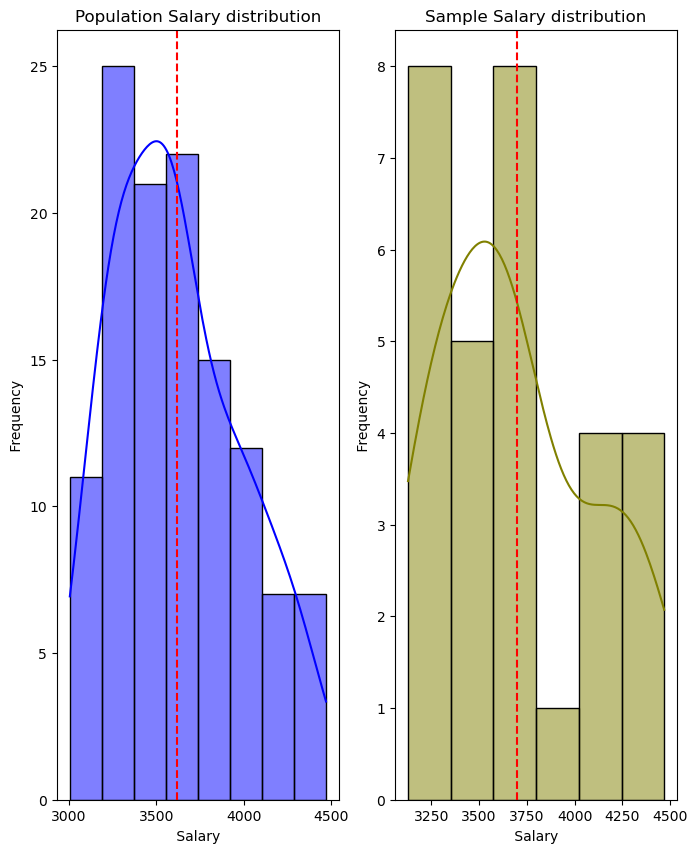

In [24]:
population_sample= population.sample(n=30, replace= False, random_state=42)
sample_mean= population_sample['salary'].mean().round(4)
population_mean= population['salary'].mean().round(4)

fig, (ax1, ax2)= plt.subplots(1, 2, figsize =(8, 10))

sns.histplot(population['salary'], color='blue', kde=True, ax= ax1)
ax1.axvline(population_mean, linestyle= '--', color= 'red')
sns.histplot(population_sample['salary'],color='olive', kde=True, ax= ax2)
ax2.axvline(sample_mean, linestyle= '--', color= 'r')

ax1.set_title('Population Salary distribution')
ax2.set_title('Sample Salary distribution')
ax1.set_xlabel(' Salary ')
ax1.set_ylabel(' Frequency ')
ax2.set_xlabel(' Salary ')
ax2.set_ylabel(' Frequency ')


plt.show()


In [25]:
pop_strat_sample= population.groupby('department').sample(n=10, random_state= 42)
print(pop_strat_sample)
print(pop_strat_sample['department'].value_counts())

    department       salary      score
99     Finance  3553.082573  78.573119
96     Finance  3659.224055  72.590223
95     Finance  3307.297010  83.312785
106    Finance  3977.237180  78.449960
84     Finance  3438.301279  68.356314
92     Finance  3459.589381  84.678012
117    Finance  3366.264392  79.305180
107    Finance  3634.915563  70.455787
119    Finance  3750.386607  83.967033
86     Finance  3783.080424  81.605247
22          HR  3310.129231  62.140134
0           HR  3374.507123  81.328256
26          HR  3127.350963  65.104394
4           HR  3264.876994  79.694857
32          HR  3297.975416  69.559802
18          HR  3163.796389  81.508138
10          HR  3230.487346  62.594693
33          HR  3141.343361  76.858030
15          HR  3215.656871  87.399475
12          HR  3336.294341  66.501570
58        Tech  4099.379029  80.412059
49        Tech  3471.087953  77.477583
77        Tech  3910.297795  82.922351
45        Tech  3784.046737  84.476686
75        Tech  4246.5707

In [30]:
first_cdf= stats.norm.cdf(3500, population['salary'].mean(), population['salary'].std())
second_sf= stats.norm.sf(4200, population['salary'].mean(), population['salary'].std())
p_range= (stats.norm.cdf(3800, population['salary'].mean(), population['salary'].std()))- (stats.norm.cdf(3300, population['salary'].mean(), population['salary'].std()))
print(f'Probability salary is less than 3500: {first_cdf:.4f}')
print(f'Probability salary is greater than 4200: {second_sf:.4f}')
print(f'Probability salary is between than 3300 and 3800: {first_cdf:.4f}')


Probability salary is less than 3500: 0.3705
Probability salary is greater than 4200: 0.0554
Probability salary is between than 3300 and 3800: 0.3705


In [44]:
ci= stats.t.interval(0.95, len(population_sample['salary'])-1, np.mean(population_sample['salary']), stats.sem(population_sample['salary']))
print(f'population Mean: {population_mean:.4f}')
print(f'sample Mean: {sample_mean:.4f}')
print(f'confidence interval: {ci}')

#the population mean falls within the confidence intervals

#I would use cluster sampling. This is because since i have the  budget to only visit 3 offices, I would visit the 3 offices, and pick my samples from the 3 offices

population Mean: 3620.1754
sample Mean: 3696.3577
confidence interval: (3545.634632307877, 3847.080825549824)
